# Experiment: SVM Baseline — Full Training Set

Same RBF-kernel SVM as `exp_02_svm_baseline.ipynb` but trained on all 57k rows.

In [1]:
import sys, os
if 'google.colab' in str(get_ipython()):
    REPO = 'diabetes-uci-dataset'
    REPO_URL = 'https://github.com/byambaa0325/diabetes-uci-dataset.git'
    if not os.path.exists(REPO):
        os.system(f'git clone {REPO_URL}')
    os.chdir(REPO)
    os.system('pip install -q -r requirements.txt')
    os.system('pip install -q -e .')
else:
    root = os.path.abspath(os.path.join(os.getcwd(), '../../'))
    if root not in sys.path:
        sys.path.insert(0, root)

In [2]:
import time
import joblib

from src.data.loader import load_raw
from src.data.preprocessor import clean, encode_target
from src.data.features import build_features
from src.models.trainers import run_training
from src.evaluation.metrics import evaluate

In [3]:
# --- Data ---
df_raw, _ = load_raw()
df = encode_target(clean(df_raw))

split = int(0.8 * len(df))
df_train, df_val = df.iloc[:split].copy(), df.iloc[split:].copy()

X_train, y_train, scaler = build_features(df_train, fit_scaler=True)
X_val,   y_val,   _      = build_features(df_val, scaler=scaler, fit_scaler=False)

print(f'Train: {X_train.shape}  (positive rate: {y_train.mean():.3f})')
print(f'Val:   {X_val.shape}')

Train: (57214, 41)  (positive rate: 0.094)
Val:   (14304, 41)


In [4]:
# --- Config ---
config = {
    'name':          'svm_rbf_full',
    'wandb_project': 'applied-ai-coursework',
    'model':         'svm',
    'model_params':  {
        'kernel':       'rbf',
        'C':            1.0,
        'gamma':        'scale',
        'probability':  True,
        'class_weight': 'balanced',
    },
    'X_train': X_train, 'y_train': y_train,
    'X_val':   X_val,   'y_val':   y_val,
}

In [5]:
# --- Train ---
t0 = time.time()
run_dir = run_training(config)
print(f'Training time: {time.time() - t0:.1f}s')
print('Artefacts saved to:', run_dir)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\byamb\_netrc.
wandb: Currently logged in as: byambaa-bayarmandakh-25 (byambaa-bayarmandakh-25-ucl) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


train_log_loss,▁
val_log_loss,▁
train_log_loss,0.2988
val_log_loss,0.24317


Run saved → E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-07_19-13-30_svm_rbf_full
Training time: 2281.5s
Artefacts saved to: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-07_19-13-30_svm_rbf_full


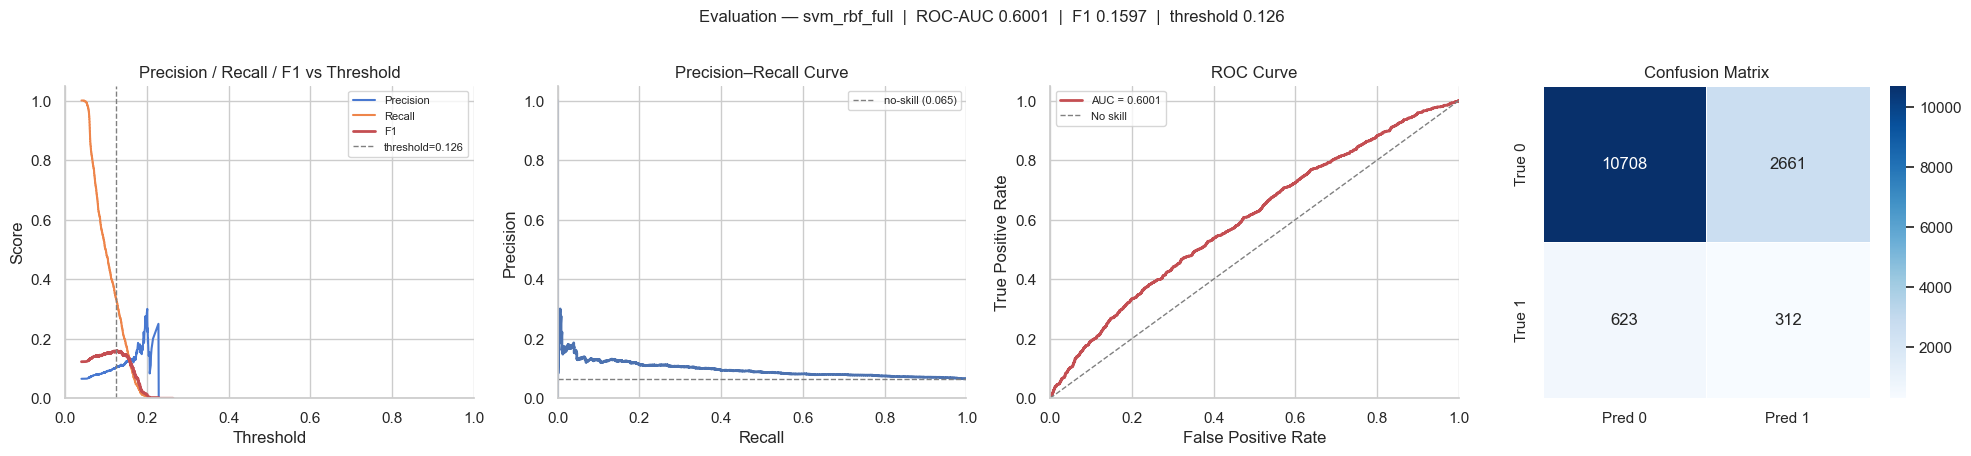

ROC-AUC  : 0.6001
Threshold: 0.126
F1       : 0.1597
Recall   : 0.3337
Precision: 0.1049


In [6]:
# --- Evaluate ---
model = joblib.load(run_dir / 'model.joblib')

results = evaluate(model, X_val, y_val, threshold=None, plot=True, title=config['name'])

print(f"ROC-AUC  : {results['roc_auc']:.4f}")
print(f"Threshold: {results['threshold']:.3f}")
print(f"F1       : {results['f1']:.4f}")
print(f"Recall   : {results['recall']:.4f}")
print(f"Precision: {results['precision']:.4f}")